# **Hotel Booking Cancellation Prediction**

In [2]:
%pip install --upgrade --force-reinstall numpy==1.23.5 pandas==1.5.3 scikit-learn==1.1.3 matplotlib seaborn

  Using cached scikit_learn-1.1.3-cp311-cp311-win_amd64.whl.metadata (10 kB)
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp311-cp311-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
INFO: pip is looking at multiple versions of matplotlib to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/80.3 kB ?

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\evoge\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,plot_confusion_matrix,precision_recall_curve,roc_curve,make_scorer
import warnings;
import numpy as np
warnings.filterwarnings('ignore')

In [24]:
hotel = pd.read_csv("INNHotelsGroup.csv")

In [25]:
data = hotel.copy()

In [26]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [27]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


In [28]:
data.shape

(36275, 19)

* The dataset has 36275 rows and 19 columns. 

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

* `Booking_ID`, `type_of_meal_plan`, `room_type_reserved`, `market_segment_type`, and `booking_status` are of object type while rest columns are numeric in nature.

* There are no null values in the dataset.

### **Dropping duplicate values**

In [30]:
# checking for duplicate values
data.duplicated().sum()

0

- There are **no duplicate values** in the data.

In [31]:
data = data.drop(["Booking_ID"], axis=1)

In [32]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


**checking the statistical summary of the data.**

In [33]:
data.describe() 

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


From this summary of statistics we can see our typical demographic which is usually throughout the weekdays is 2 adults presumably a couple. Which can be insightful for marketing team.

## **Exploratory Data Analysis**

In [34]:
# Defining the hist_box() function
def hist_box(data,col):
  f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12,6))
  # Adding a graph in each part
  sns.boxplot(data[col], ax=ax_box, showmeans=True)
  sns.distplot(data[col], ax=ax_hist)
  plt.show()

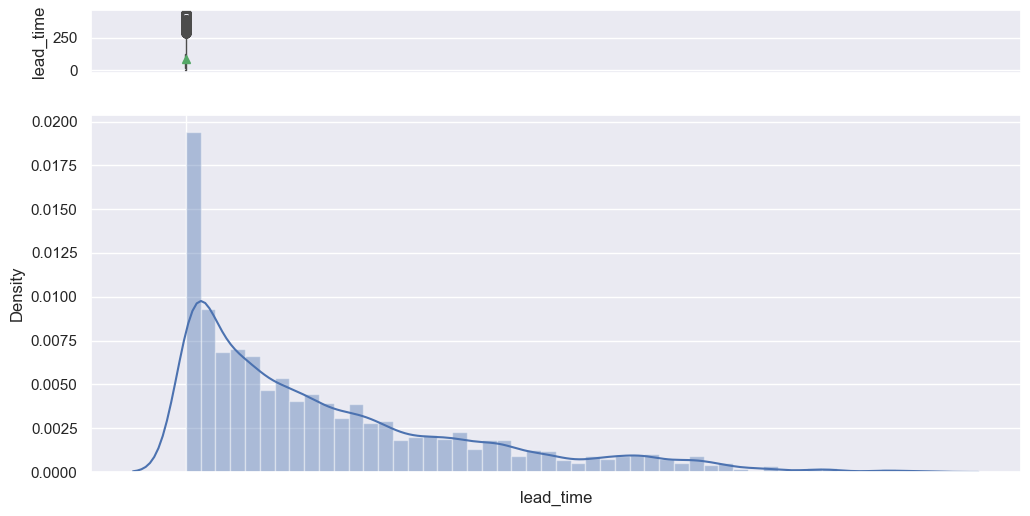

In [35]:
hist_box(data, "lead_time") 

the lead_time data is very right skewed, which is displayed in the shape of the hitogram,apporoximately 50% of bookings are made with between 10 and 300 days of lead time. which is a large spread.

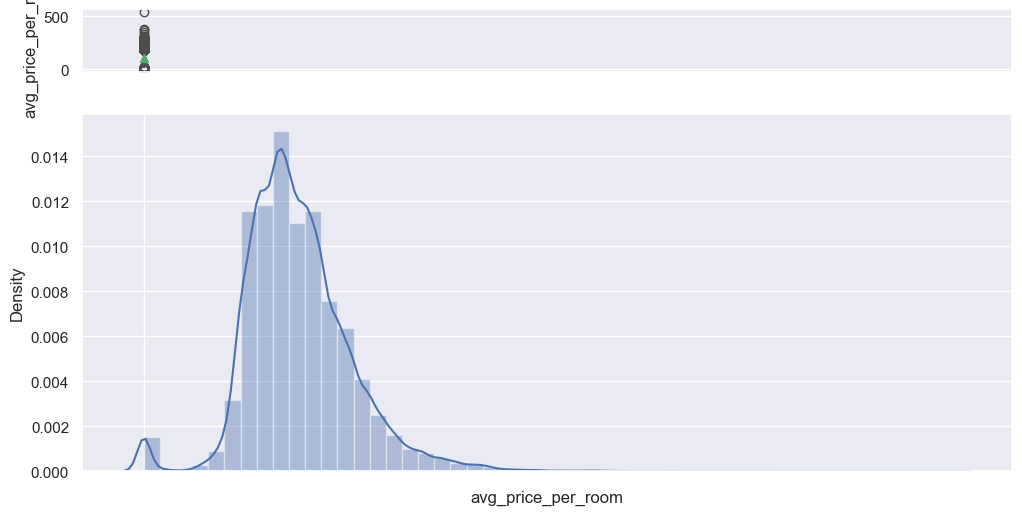

In [36]:
hist_box(data, "avg_price_per_room")

Here we can see that the average price per room is centered around roughly 100$, but displays right and left skew on our data set. which indicates that the mean value is higher than the median value

**Interestingly some rooms have a price equal to 0. Let's check them.**

In [37]:
data[data["avg_price_per_room"] == 0]

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.0,1,Not_Canceled
145,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,Not_Canceled
209,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,Not_Canceled
266,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,Not_Canceled
267,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.0,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,1,0,0,1,Meal Plan 1,0,Room_Type 7,0,2018,6,7,Complementary,1,4,17,0.0,1,Not_Canceled
36080,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.0,1,Not_Canceled
36114,1,0,0,1,Meal Plan 1,0,Room_Type 1,1,2018,3,2,Online,0,0,0,0.0,0,Not_Canceled
36217,2,0,2,1,Meal Plan 1,0,Room_Type 2,3,2017,8,9,Online,0,0,0,0.0,2,Not_Canceled


- There are quite a few hotel rooms which have a price equal to 0.
- In the market segment column, it looks like many values are complementary.

In [38]:
data.loc[data["avg_price_per_room"] == 0, "market_segment_type"].value_counts()

Complementary    354
Online           191
Name: market_segment_type, dtype: int64

* It makes sense that most values with room prices equal to 0 are the rooms given as complimentary service from the hotel.
* The rooms booked online must be a part of some promotional campaign done by the hotel.

In [39]:
# Calculating the 25th quantile
Q1 = data["avg_price_per_room"].quantile(0.25)

# Calculating the 75th quantile
Q3 = data["avg_price_per_room"].quantile(0.75)

# Calculating IQR
IQR = Q3 - Q1

# Calculating value of upper whisker
Upper_Whisker = Q3 + 1.5 * IQR
print("upper Whisker", Upper_Whisker)

upper Whisker 179.55


In [40]:
# assigning the outliers the value of upper whisker
data.loc[data["avg_price_per_room"] >= 500, "avg_price_per_room"] = Upper_Whisker

**Number of Children**

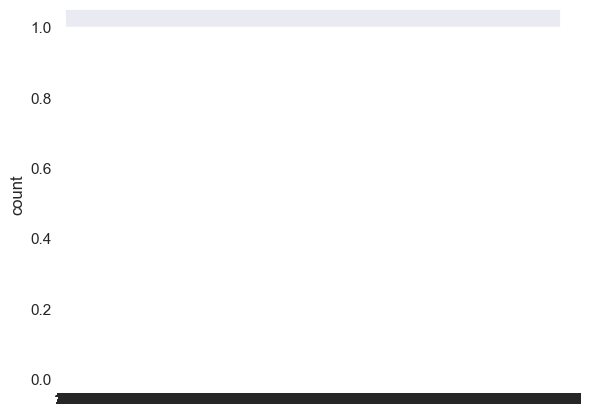

In [41]:
sns.countplot(data['no_of_children'])
plt.show()

In [42]:
data['no_of_children'].value_counts(normalize=True)

0     0.925624
1     0.044604
2     0.029166
3     0.000524
9     0.000055
10    0.000028
Name: no_of_children, dtype: float64

* Customers were not travelling with children in 93% of cases.
* There are some values in the data where the number of children is 9 or 10, which is highly unlikely. 
* We will replace these values with the maximum value of 3 children.

In [43]:
# replacing 9, and 10 children with 3
data["no_of_children"] = data["no_of_children"].replace([9, 10], 3)

**Arrival Month**

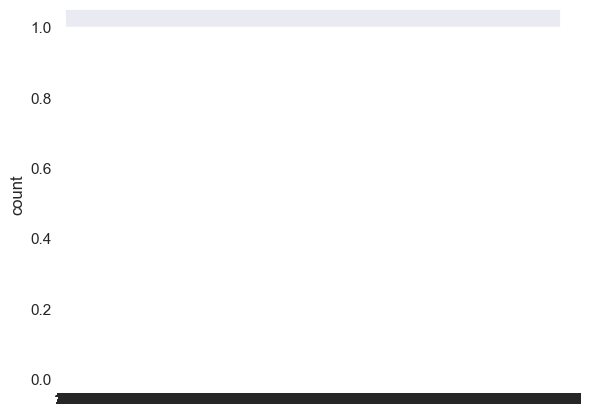

In [44]:
sns.countplot(data["arrival_month"])
plt.show()

In [45]:
data['arrival_month'].value_counts(normalize=True)

10    0.146575
9     0.127112
8     0.105114
6     0.088298
12    0.083280
11    0.082150
7     0.080496
4     0.075424
5     0.071620
3     0.065003
2     0.046975
1     0.027953
Name: arrival_month, dtype: float64

* October is the busiest month for hotel arrivals followed by September and August. **Over 35% of all bookings**, as we see in the above table, were for one of these three months.
* Around 14.7% of the bookings were made for an October arrival.

**Booking Status**

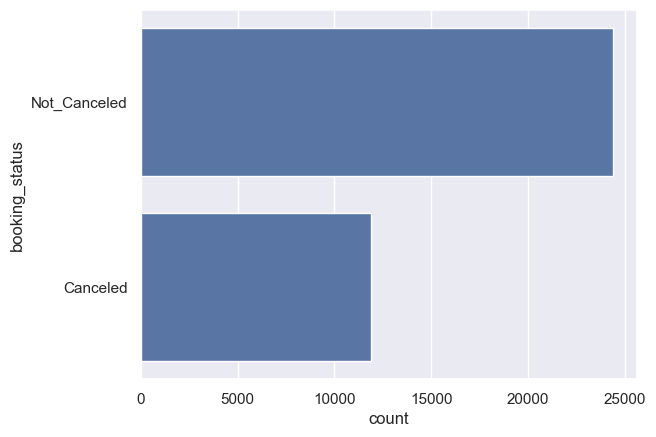

In [46]:
sns.countplot(data["booking_status"])
plt.show()

In [47]:
data['booking_status'].value_counts(normalize=True)

Not_Canceled    0.672364
Canceled        0.327636
Name: booking_status, dtype: float64

* 32.8% of the bookings were canceled by the customers.

**Let's encode Canceled bookings to 1 and Not_Canceled as 0 for further analysis**

In [48]:
data["booking_status"] = data["booking_status"].apply(
    lambda x: 1 if x == "Canceled" else 0
)

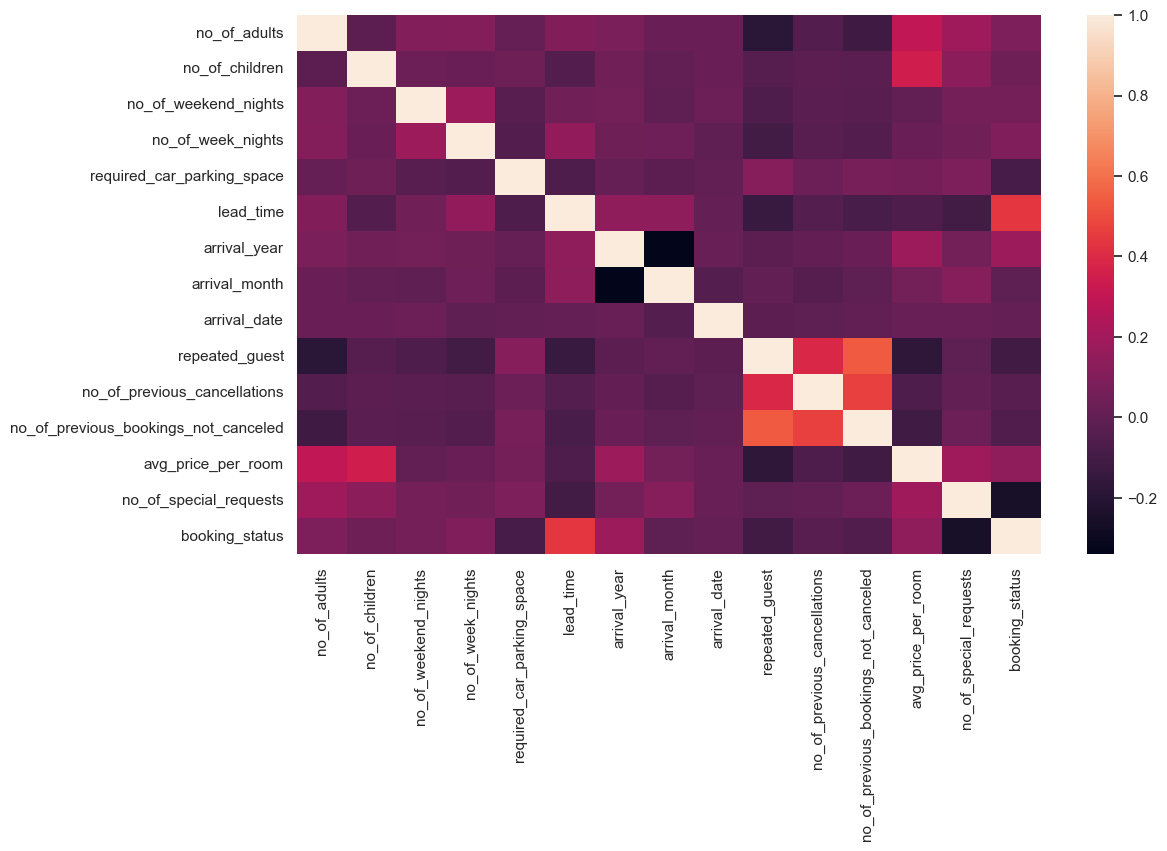

In [49]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(data.corr())
plt.show()

The heatmap indicates a correlation between specific data points, with a relatively high heat area around "repeated_guest", "no_prev_cancellations", and "no_previous_not_cancellation". Additionally, the following observations can be made:

1. Repeat guests tend to have a higher number of both cancellations and non-cancellations.
2. There is a correlation between the average room price and the number of children and adults, with larger families having higher bills.

**Hotel rates are dynamic and change according to demand and customer demographics. Let's see how prices vary across different market segments**

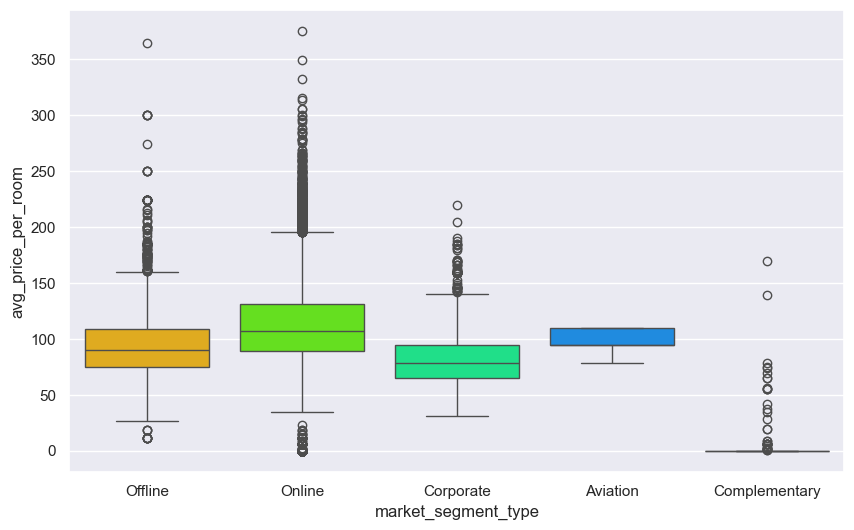

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data, x="market_segment_type", y="avg_price_per_room", palette="gist_rainbow"
)
plt.show()

* Rooms booked online have high variations in prices.
* The offline and corporate room prices are almost similar.
* Complementary market segment gets the rooms at very low prices, which makes sense.

In [51]:
# Defining the stacked_barplot() function
def stacked_barplot(data,predictor,target,figsize=(10,6)):
  (pd.crosstab(data[predictor],data[target],normalize='index')*100).plot(kind='bar',figsize=figsize,stacked=True)
  plt.legend(loc="lower right")
  plt.ylabel('Percentage Cancellations %')

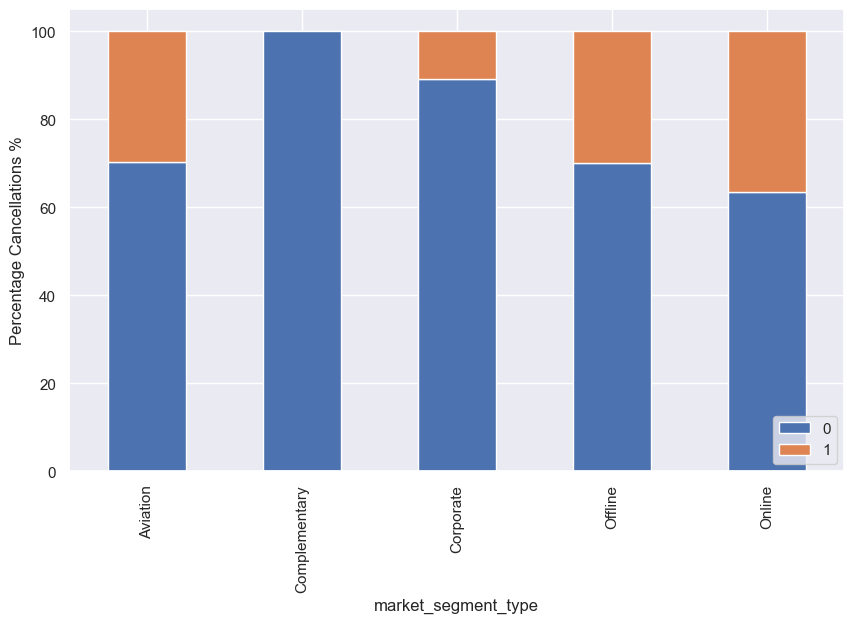

In [52]:
# Plot the stacked barplot for the variable `Market Segment Type` against the target variable `Booking Status`
stacked_barplot(data, "market_segment_type", "booking_status")

Corporate and Complementary market segmant type bookings had the lowest occurance of cancellations whereas aviation and online bookings had the highest chance of cancellations


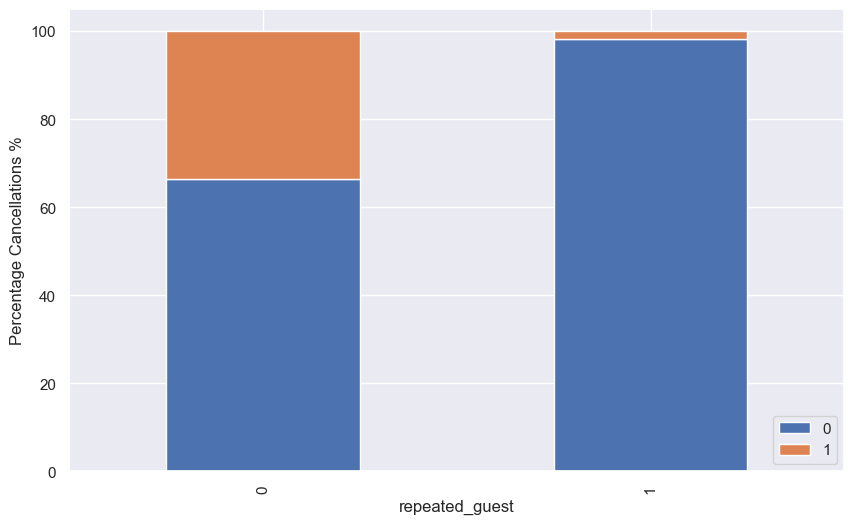

In [53]:
stacked_barplot(data, "repeated_guest", "booking_status")


Repeat customers have much fewer cancellations than bookings made by guests who had no prior bookings.


**Let's analyze the customer who stayed for at least a day at the hotel.**

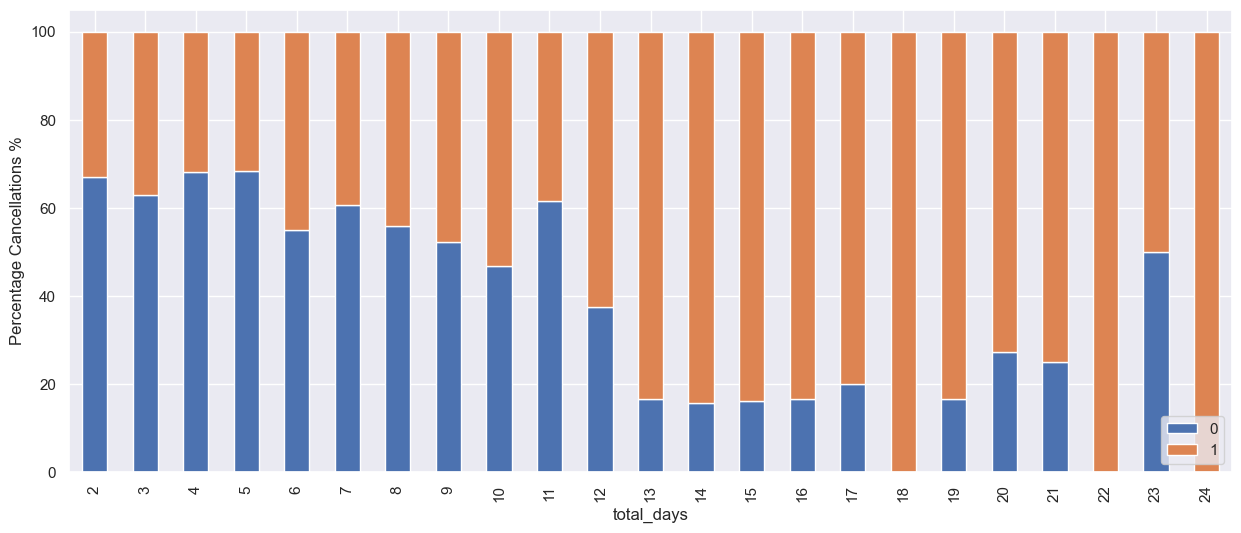

In [54]:
stay_data = data[(data["no_of_week_nights"] > 0) & (data["no_of_weekend_nights"] > 0)]
stay_data["total_days"] = (stay_data["no_of_week_nights"] + stay_data["no_of_weekend_nights"])

stacked_barplot(stay_data, "total_days", "booking_status",figsize=(15,6))

* The general trend is that the chances of cancellation increase as the number of days the customer planned to stay at the hotel increases.

**As hotel room prices are dynamic, Let's see how the prices vary across different months**

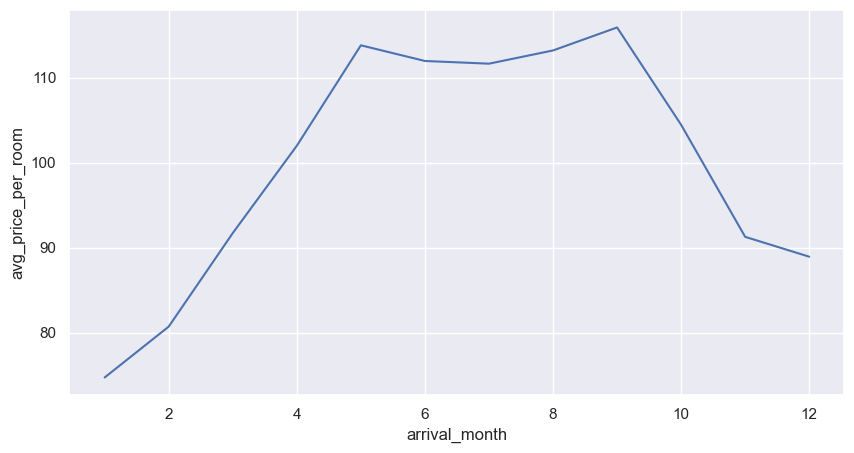

In [55]:
plt.figure(figsize=(10, 5))
sns.lineplot(y=data["avg_price_per_room"], x=data["arrival_month"], ci=None)
plt.show()

* The price of rooms is highest in May to September - around 115 euros per room.

**Separating the independent variables (X) and the dependent variable (Y)**

In [56]:
X = data.drop(["booking_status"], axis=1)
Y = data["booking_status"]

X = pd.get_dummies(X, drop_first=True) # Encoding the Categorical features

In [57]:
# Splitting data in train and test sets 70/30
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30,stratify=Y, random_state=1)

In [58]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (25392, 27)
Shape of test set :  (10883, 27)
Percentage of classes in training set:
0    0.672377
1    0.327623
Name: booking_status, dtype: float64
Percentage of classes in test set:
0    0.672333
1    0.327667
Name: booking_status, dtype: float64


In [59]:
# Creating metric function 
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Cancelled', 'Cancelled'], yticklabels=['Not Cancelled', 'Cancelled'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [60]:
# Fitting logistic regression model
lg = LogisticRegression()
lg.fit(X_train, y_train)

LogisticRegression()

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     17073
           1       0.73      0.60      0.65      8319

    accuracy                           0.79     25392
   macro avg       0.77      0.74      0.75     25392
weighted avg       0.79      0.79      0.79     25392



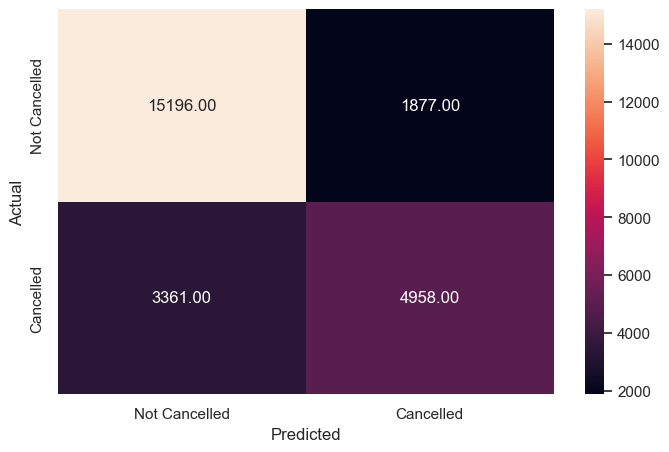

In [61]:
# Checking the performance on the training data
y_pred_train = lg.predict(X_train)
metrics_score(y_train, y_pred_train)

This model performs better predicting 'Non Cancelled' bookings in contrast to ' Cancelled ' bookings as displayed by the higher precision , recall , and f- stat values associated with the ' Not Cancelled ' than ' Cancelled ' lines of the table .


              precision    recall  f1-score   support

           0       0.82      0.89      0.85      7317
           1       0.72      0.59      0.65      3566

    accuracy                           0.79     10883
   macro avg       0.77      0.74      0.75     10883
weighted avg       0.78      0.79      0.78     10883



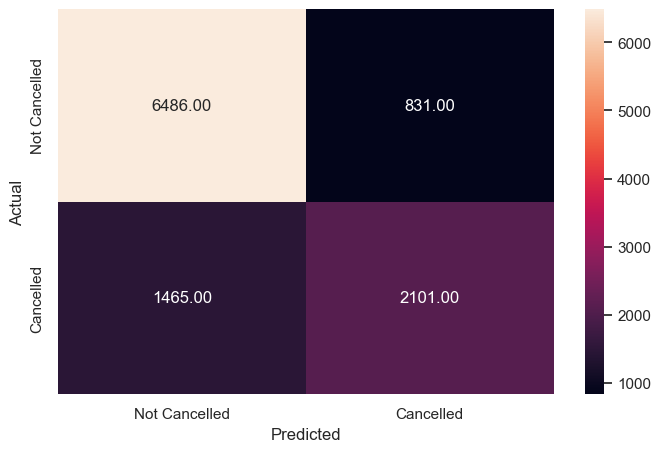

In [62]:
# Checking the performance on the test dataset
y_pred_test = lg.predict(X_test)
metrics_score(y_test, y_pred_test)

The model performs similar on the test data as on the training data , tending to better predict the ' Not Cancelled ' bookings than the ' Cancelled ' bookings . Precision , recall , and f-stat values for the test data are very close to those produced by the training data showing the model is not overfit.


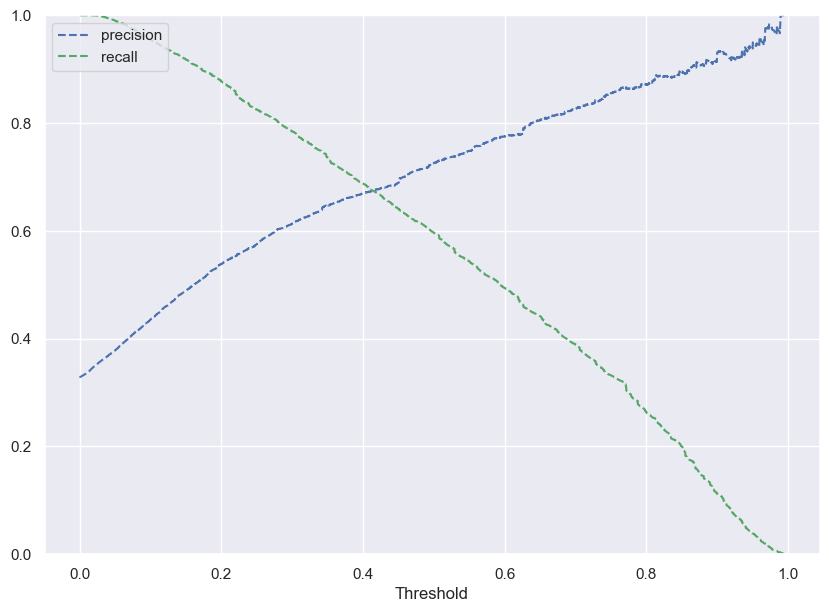

In [63]:
# Predict_proba gives the probability of each observation belonging to each class
y_scores_lg=lg.predict_proba(X_train)

precisions_lg, recalls_lg, thresholds_lg = precision_recall_curve(y_train, y_scores_lg[:,1])

# Plot values of precisions, recalls, and thresholds
plt.figure(figsize=(10,7))
plt.plot(thresholds_lg, precisions_lg[:-1], 'b--', label='precision')
plt.plot(thresholds_lg, recalls_lg[:-1], 'g--', label = 'recall')
plt.xlabel('Threshold')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.show()

#### precision and recall are balanced at a similar threshold of 0.41

In [64]:
# Setting the optimal threshold
optimal_threshold = 0.41

              precision    recall  f1-score   support

           0       0.84      0.84      0.84     17073
           1       0.67      0.68      0.67      8319

    accuracy                           0.79     25392
   macro avg       0.76      0.76      0.76     25392
weighted avg       0.79      0.79      0.79     25392



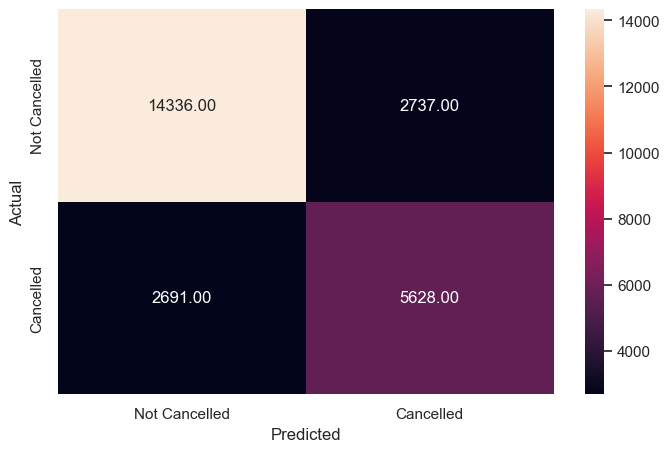

In [65]:
# Creating confusion matrix
y_pred_train = lg.predict_proba(X_train)
metrics_score(y_train, y_pred_train[:,1] > optimal_threshold)

### The following points summarize the effects of changing the threshold for this predictive model

- Increasing the threshold led to higher precision and lower recall for the "Not Cancelled" prediction, and lower f-stat in general.
- Decreasing the threshold led to decreases in all categories for the "Cancelled" prediction.
- The "Not Cancelled" metrics were less sensitive to threshold adjustments compared to the "Cancelled" metrics.
- The average model values were not significantly changed by the threshold adjustment.
- Increasing precision for a classification resulted in a decrease in recall for that particular classification and vice versa.


              precision    recall  f1-score   support

           0       0.84      0.84      0.84      7317
           1       0.66      0.66      0.66      3566

    accuracy                           0.78     10883
   macro avg       0.75      0.75      0.75     10883
weighted avg       0.78      0.78      0.78     10883



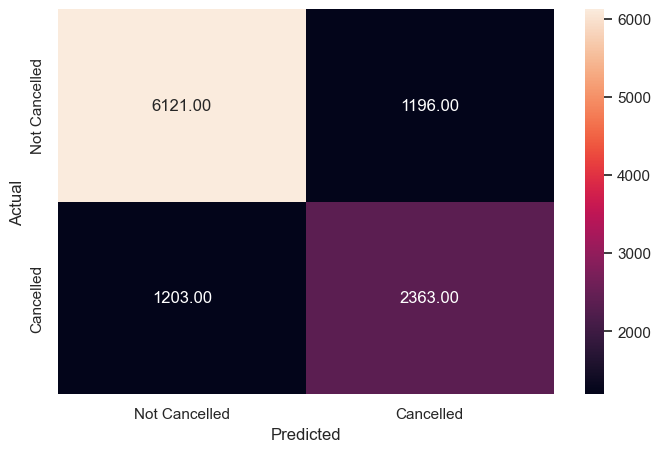

In [66]:
y_pred_test = lg.predict_proba(X_test)
metrics_score(y_test, y_pred_test[:,1] > optimal_threshold)

- The optimized threshold model was found to be similar in accuracy to the fitment of the training data.
- This similarity indicates that the model is not overfit and has generalizability.
- The new threshold has resulted in increased levels of precision for cancelled bookings and decreased the 'f-stat' value for 'not cancelled' bookings.
- These changes indicate an overall change in accuracy between classifications.
- Specifically, there is increased accuracy in predicting cancelled bookings but decreased accuracy in predicting the 'not cancelled' bookings.

In [67]:
scaling = MinMaxScaler(feature_range=(-1,1)).fit(X_train)
X_train_scaled = scaling.transform(X_train)
X_test_scaled = scaling.transform(X_test)

In [68]:
svm = SVC(kernel='linear',probability=True) # Linear kernal or linear decision boundary
model = svm.fit(X_train_scaled, y_train)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86     17073
           1       0.74      0.61      0.67      8319

    accuracy                           0.80     25392
   macro avg       0.79      0.76      0.77     25392
weighted avg       0.80      0.80      0.80     25392



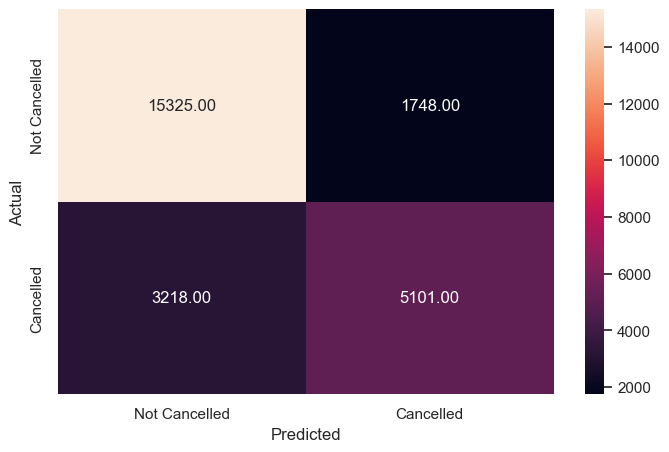

In [69]:
y_pred_train_svm = model.predict(X_train_scaled)
metrics_score(y_train, y_pred_train_svm)

The DVM model had a similar fit to the Logistic Model. With the SVM model having a higher precision, recall, and f-stat for the 'non cancelled', the training data was very similar to the average values of the fitment assessment.

Checking model performance on test set

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      7317
           1       0.74      0.61      0.67      3566

    accuracy                           0.80     10883
   macro avg       0.78      0.75      0.76     10883
weighted avg       0.80      0.80      0.80     10883



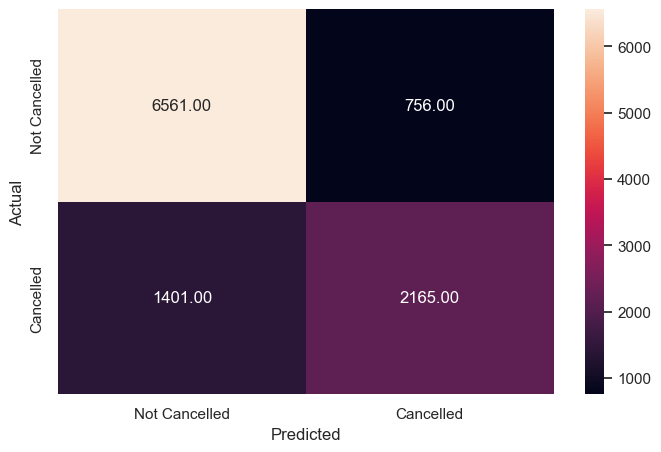

In [70]:
y_pred_test_svm = model.predict(X_test_scaled)
metrics_score(y_test, y_pred_test_svm)

overall average accuracy metrics were very similar to the training data fitment, again having better prediction for the 'not cancelled' classification

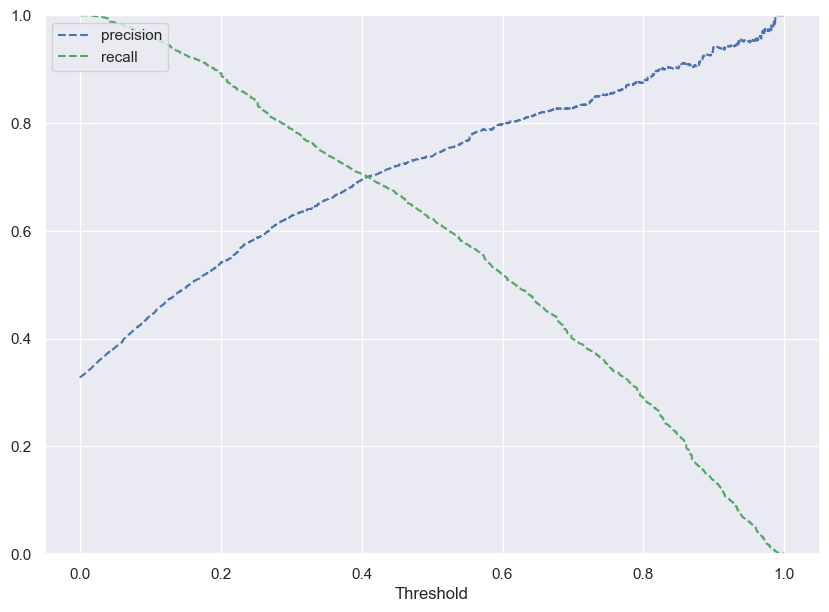

In [71]:
# Predict on train data
y_scores_svm=model.predict_proba(X_train_scaled)

precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(y_train, y_scores_svm[:,1])

# Plot values of precisions, recalls, and thresholds
plt.figure(figsize=(10,7))
plt.plot(thresholds_svm, precisions_svm[:-1], 'b--', label='precision')
plt.plot(thresholds_svm, recalls_svm[:-1], 'g--', label = 'recall')
plt.xlabel('Threshold')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.show()

precision and recall are the same at 0.41


In [72]:
optimal_threshold_svm=0.41

              precision    recall  f1-score   support

           0       0.83      0.90      0.86     17073
           1       0.74      0.61      0.67      8319

    accuracy                           0.80     25392
   macro avg       0.79      0.76      0.77     25392
weighted avg       0.80      0.80      0.80     25392



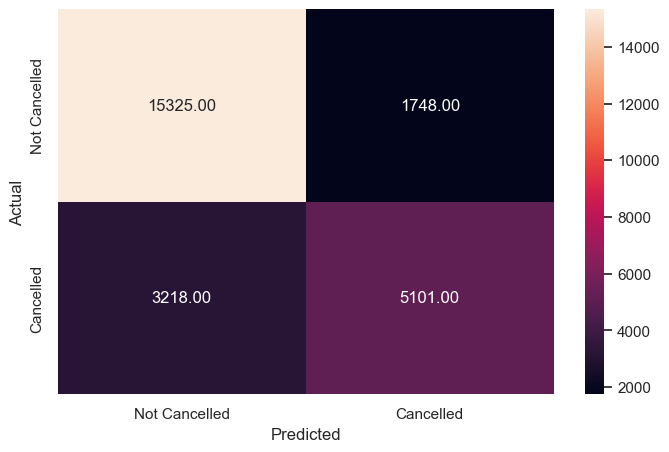

In [73]:
y_pred_train_svm = model.predict(X_train_scaled)
metrics_score(y_train, y_pred_train_svm > optimal_threshold_svm)

the optimization of the threshold value did not have any effect on the model fit to the training data


              precision    recall  f1-score   support

           0       0.82      0.90      0.86      7317
           1       0.74      0.61      0.67      3566

    accuracy                           0.80     10883
   macro avg       0.78      0.75      0.76     10883
weighted avg       0.80      0.80      0.80     10883



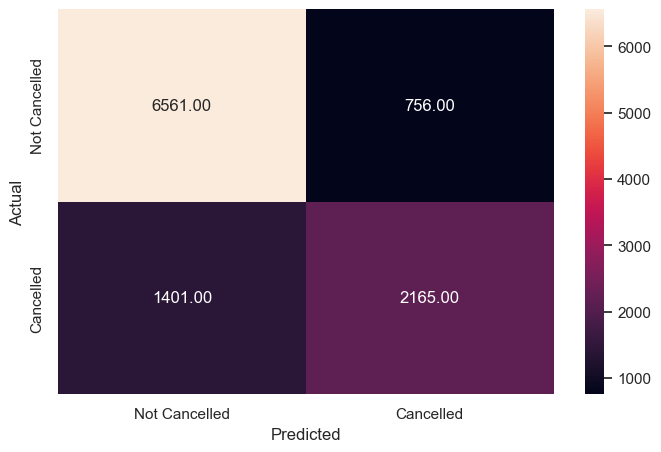

In [74]:
y_pred_test = model.predict(X_test_scaled)
metrics_score(y_test, y_pred_test > optimal_threshold_svm)

With the threshold not changing again this should conclude that the linear SVM method, derives the optimal threshold from the beginning


In [75]:
svm_rbf=SVC(kernel='rbf',probability=True)
svm_rbf.fit(X_train_scaled, y_train)

SVC(probability=True)

              precision    recall  f1-score   support

           0       0.84      0.91      0.88     17073
           1       0.79      0.65      0.71      8319

    accuracy                           0.83     25392
   macro avg       0.81      0.78      0.80     25392
weighted avg       0.82      0.83      0.82     25392



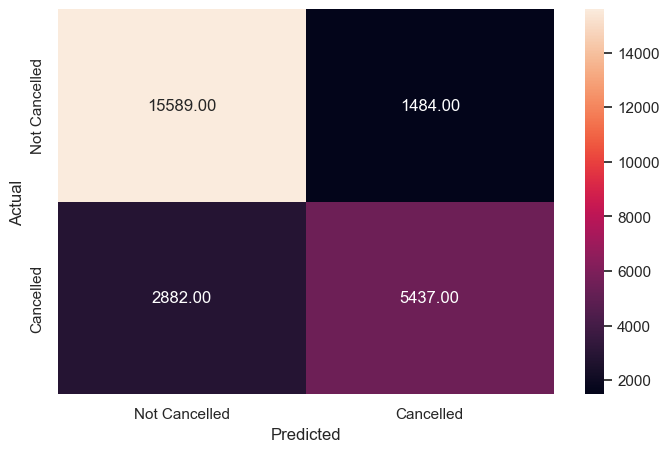

In [76]:
y_pred_train_svm = svm_rbf.predict(X_train_scaled)
metrics_score(y_train, y_pred_train_svm)

The RBF kernel SVM and the linear SVM had similar accuracy within the 'not cancelled' classification in the training data. but shows an increase in accuracy for the 'cancelled' classificaiton.

#### Checking model performance on test set

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      7317
           1       0.78      0.63      0.70      3566

    accuracy                           0.82     10883
   macro avg       0.81      0.77      0.78     10883
weighted avg       0.82      0.82      0.81     10883



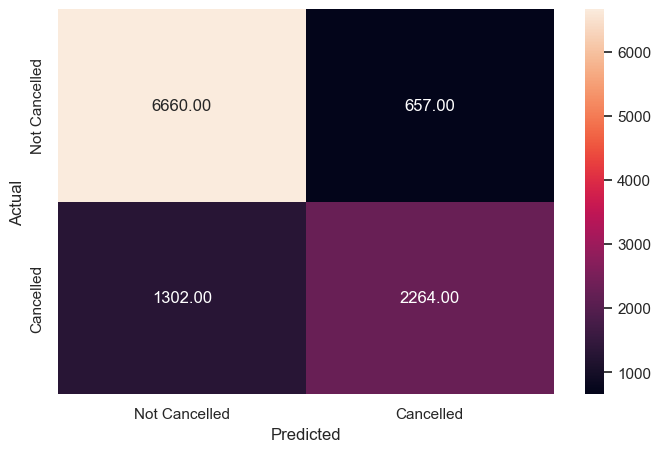

In [77]:
y_pred_test = svm_rbf.predict(X_test_scaled)

metrics_score(y_test, y_pred_test)

The RBF kernel SVM fit had similar accuracy metrics for each classification ('Cancelled' and 'Not Cancelled') with similar overall accuracy; indicating the model is not overfit.

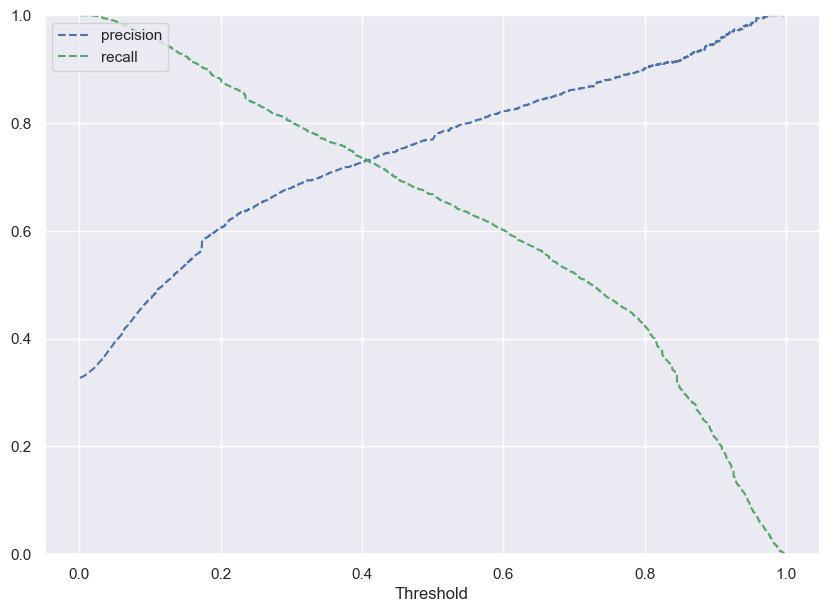

In [78]:
# Predict on train data
y_scores_svm=svm_rbf.predict_proba(X_train_scaled)

precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(y_train, y_scores_svm[:,1])

# Plot values of precisions, recalls, and thresholds
plt.figure(figsize=(10,7))
plt.plot(thresholds_svm, precisions_svm[:-1], 'b--', label='precision')
plt.plot(thresholds_svm, recalls_svm[:-1], 'g--', label = 'recall')
plt.xlabel('Threshold')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.show()

In [79]:
optimal_threshold_svm=0.40

              precision    recall  f1-score   support

           0       0.86      0.85      0.85     17073
           1       0.69      0.71      0.70      8319

    accuracy                           0.80     25392
   macro avg       0.77      0.78      0.78     25392
weighted avg       0.80      0.80      0.80     25392



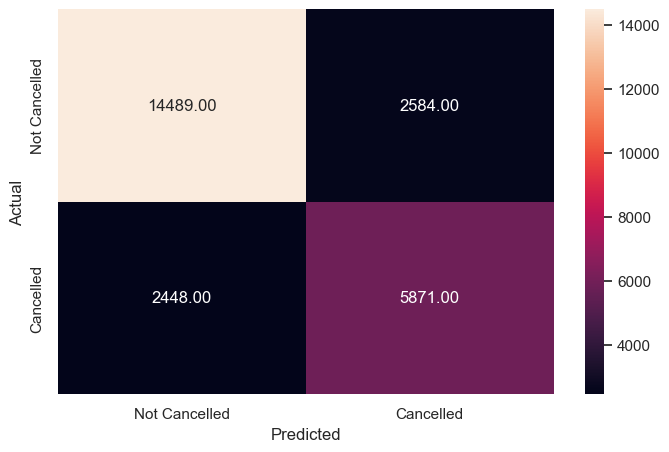

In [80]:
y_pred_train_svm = model.predict_proba(X_train_scaled)
metrics_score(y_train, y_pred_train_svm[:,1]>optimal_threshold_svm)

the optimized threshold RBF kernel SVM reduced false positives and has increased precision when predicting the 'not cancelled' classification, while reducing false negatives; aswell as a slightly improved average accuracy metrics over the non optimized model.

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      7317
           1       0.72      0.72      0.72      3566

    accuracy                           0.82     10883
   macro avg       0.79      0.79      0.79     10883
weighted avg       0.81      0.82      0.81     10883



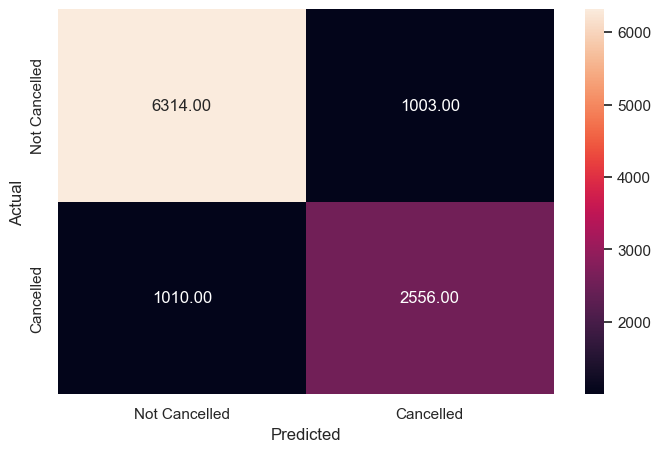

In [81]:
y_pred_test = svm_rbf.predict_proba(X_test_scaled)
metrics_score(y_test, y_pred_test[:,1]> optimal_threshold)

The optimized threshold RBF Kernel SVM fit the test data with similar results to the training data, maintaining general trends and accuracy metrics for each classification as well as overall model metrics, and also displays similar improvements over the non-optimized fit to the test data.

In [82]:
cancel_prob = data.booking_status.value_counts(normalize = True)

model_dt = DecisionTreeClassifier(class_weight = {0: cancel_prob[0], 1:cancel_prob[1]}, random_state = 1)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.6723638869745003,
                                     1: 0.32763611302549966},
                       random_state=1)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17073
           1       1.00      0.98      0.99      8319

    accuracy                           0.99     25392
   macro avg       1.00      0.99      0.99     25392
weighted avg       0.99      0.99      0.99     25392



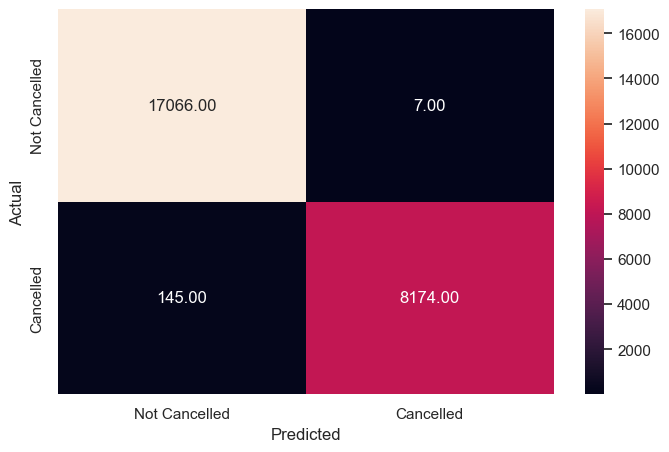

In [83]:
# Checking performance on the training dataset
pred_train_dt = model_dt.predict(X_train)
metrics_score(y_train, pred_train_dt)

the decision tree model outperformed other modeling methods with higher prediction, and recall levels for both classifications ('cancelled' and 'not cancelled') aswell as a greater overall accuracy.

#### Checking model performance on test set

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      7317
           1       0.79      0.80      0.79      3566

    accuracy                           0.86     10883
   macro avg       0.85      0.85      0.85     10883
weighted avg       0.86      0.86      0.86     10883



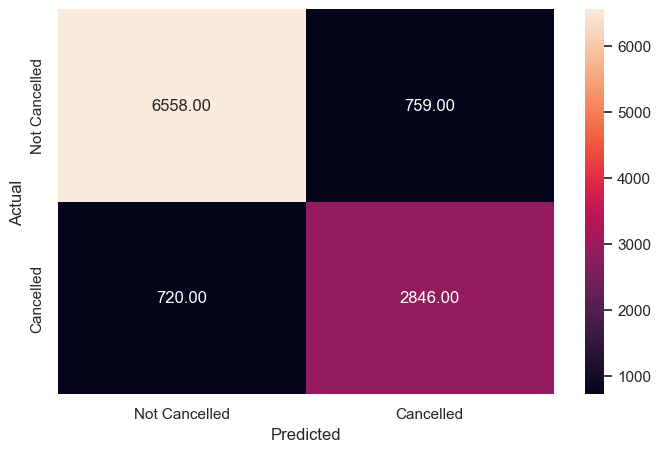

In [84]:
pred_test_dt = model_dt.predict(X_test)
metrics_score(y_test, pred_test_dt)

the decision tree model did not fit the test data as well as the training data, reducing the accuracy for the 'not cancelled' classificaiton by as much as 10% and 20% in 'cancelled' classificaiton, the performance notably less accurate than the fit to the training dat which indicates overfit. however this method is overall more accurate than previous examples.

In [85]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(class_weight = {0 : cancel_prob [ 0 ] , 1 : cancel_prob [ 1 ] } , random_state=1 )

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(2, 7, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}


# Run the grid search
grid_obj = GridSearchCV(estimator, parameters)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.6723638869745003,
                                     1: 0.32763611302549966},
                       max_depth=6, max_leaf_nodes=50, min_samples_split=10,
                       random_state=1)

#### Checking performance on the training set 

              precision    recall  f1-score   support

           0       0.82      0.97      0.89     17073
           1       0.89      0.56      0.69      8319

    accuracy                           0.83     25392
   macro avg       0.86      0.76      0.79     25392
weighted avg       0.84      0.83      0.82     25392



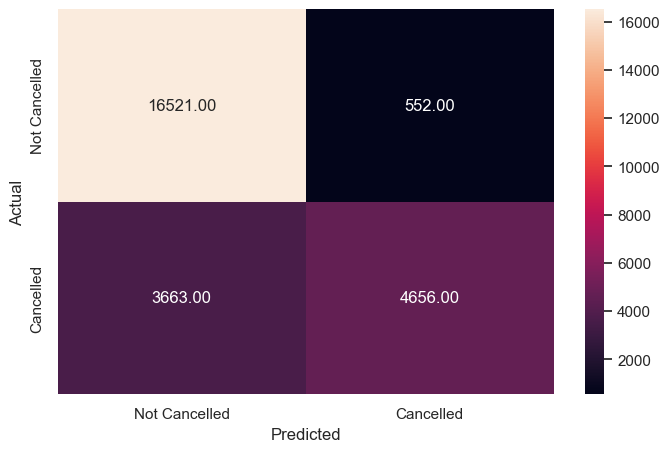

In [86]:
# Checking performance on the training dataset
dt_tuned = estimator.predict(X_train)
metrics_score(y_train, dt_tuned)

the tuned model was not as effective as the untuned model, but exhibited similar trends with predicting 'not cancelled' better than 'cancelled' classifications, however the fitment is not as apparent as the untuned model.

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      7317
           1       0.89      0.56      0.68      3566

    accuracy                           0.83     10883
   macro avg       0.85      0.76      0.79     10883
weighted avg       0.84      0.83      0.82     10883



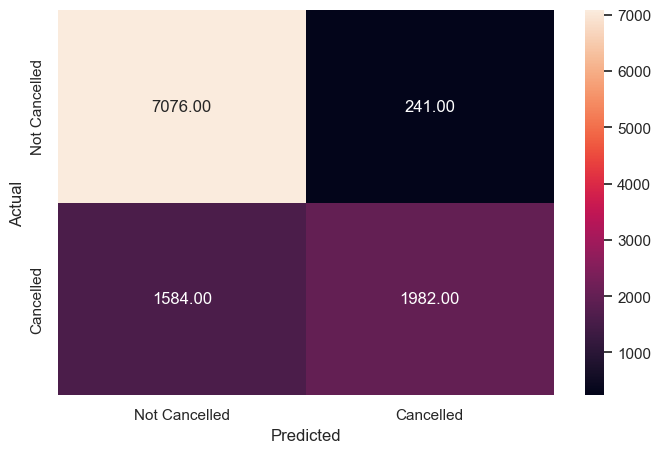

In [87]:
# Checking performance on the training dataset
y_pred_tuned = estimator.predict(X_test)
metrics_score(y_test, y_pred_tuned)

this tuned model seems to be a better overall fit for the dataset and is not overfitting the training data, however the prediction accuracy is affected.

#### **Visualizing the Decision Tree**

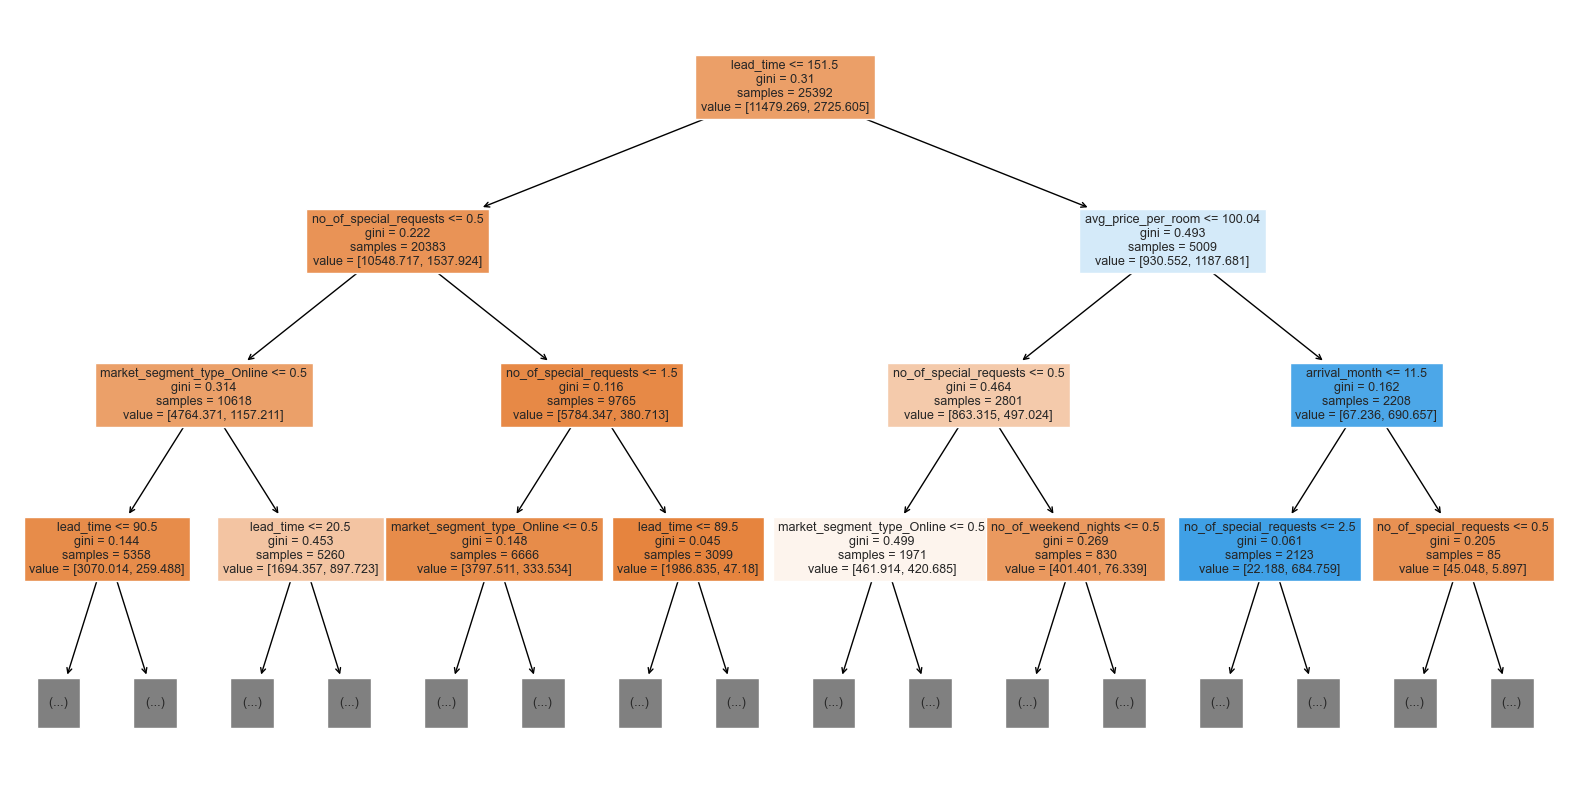

In [88]:
feature_names = list(X_train.columns)
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,max_depth=3,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

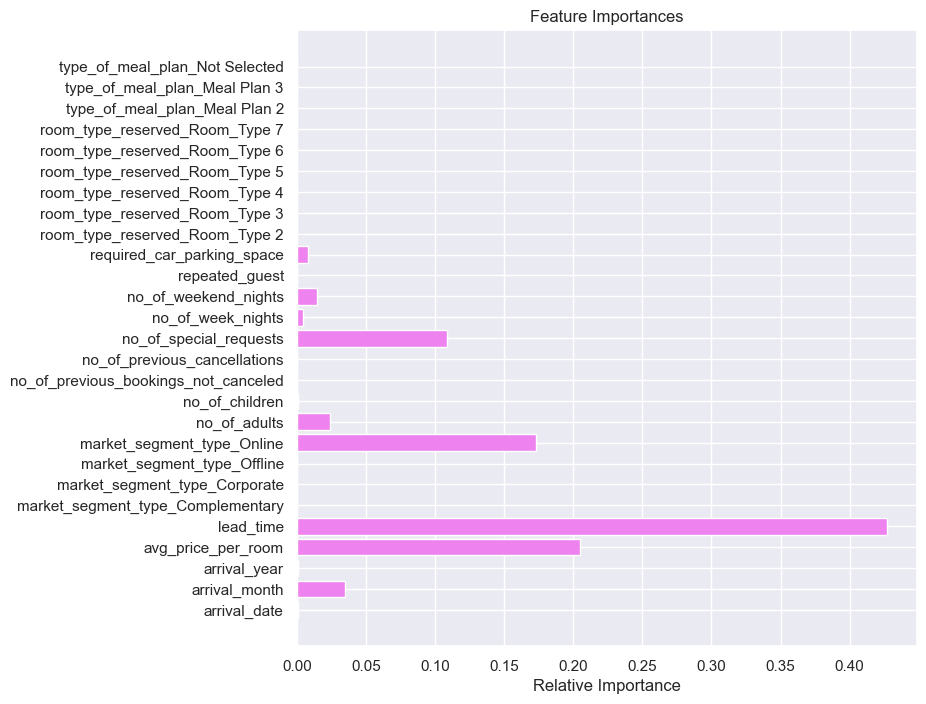

In [89]:
# Importance of features in the tree building

importances = estimator.feature_importances_
indices = np.argsort(X_train.columns)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Lead Time seems to have the highest importance, 2nd to average_price_per_room


In [90]:
rf_estimator = RandomForestClassifier(class_weight = {0: cancel_prob[0], 1: cancel_prob[1]}, random_state = 1)

rf_estimator.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.6723638869745003,
                                     1: 0.32763611302549966},
                       random_state=1)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17073
           1       1.00      0.98      0.99      8319

    accuracy                           0.99     25392
   macro avg       1.00      0.99      0.99     25392
weighted avg       0.99      0.99      0.99     25392



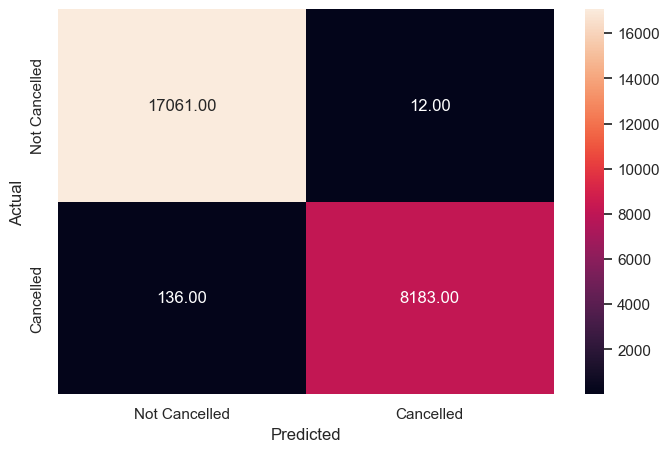

In [91]:
y_pred_train_rf = rf_estimator.predict(X_train)

metrics_score(y_train, y_pred_train_rf)

the random forest model fits the training data very well, with immense precision and recall for both classifications, however the accuracy measure values indicate that the model is overfitting.

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7317
           1       0.88      0.80      0.84      3566

    accuracy                           0.90     10883
   macro avg       0.89      0.87      0.88     10883
weighted avg       0.90      0.90      0.90     10883



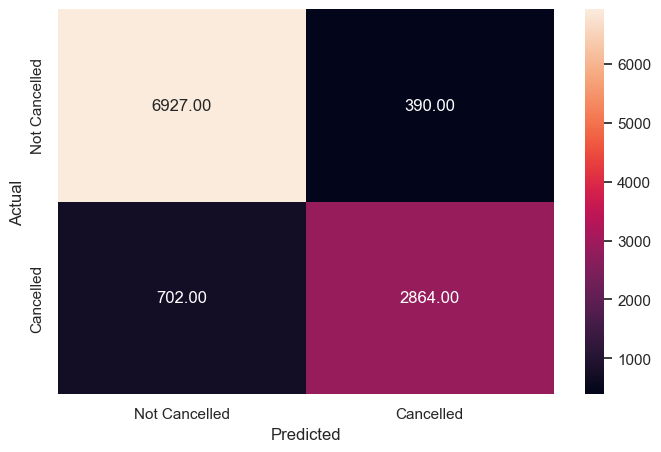

In [92]:
y_pred_test_rf = rf_estimator.predict(X_test)

metrics_score(y_test, y_pred_test_rf)

The random forest model fit the test data with less accuracy than the training data, indicating the model overfitting the training data. the 'not cancelled' classification decreased in acccuracy by 5-10% and the 'cancelled' classification accuracy decreased about 10-20%

Let's check the feature importance of the Random Forest

<Axes: xlabel='Importance', ylabel='None'>

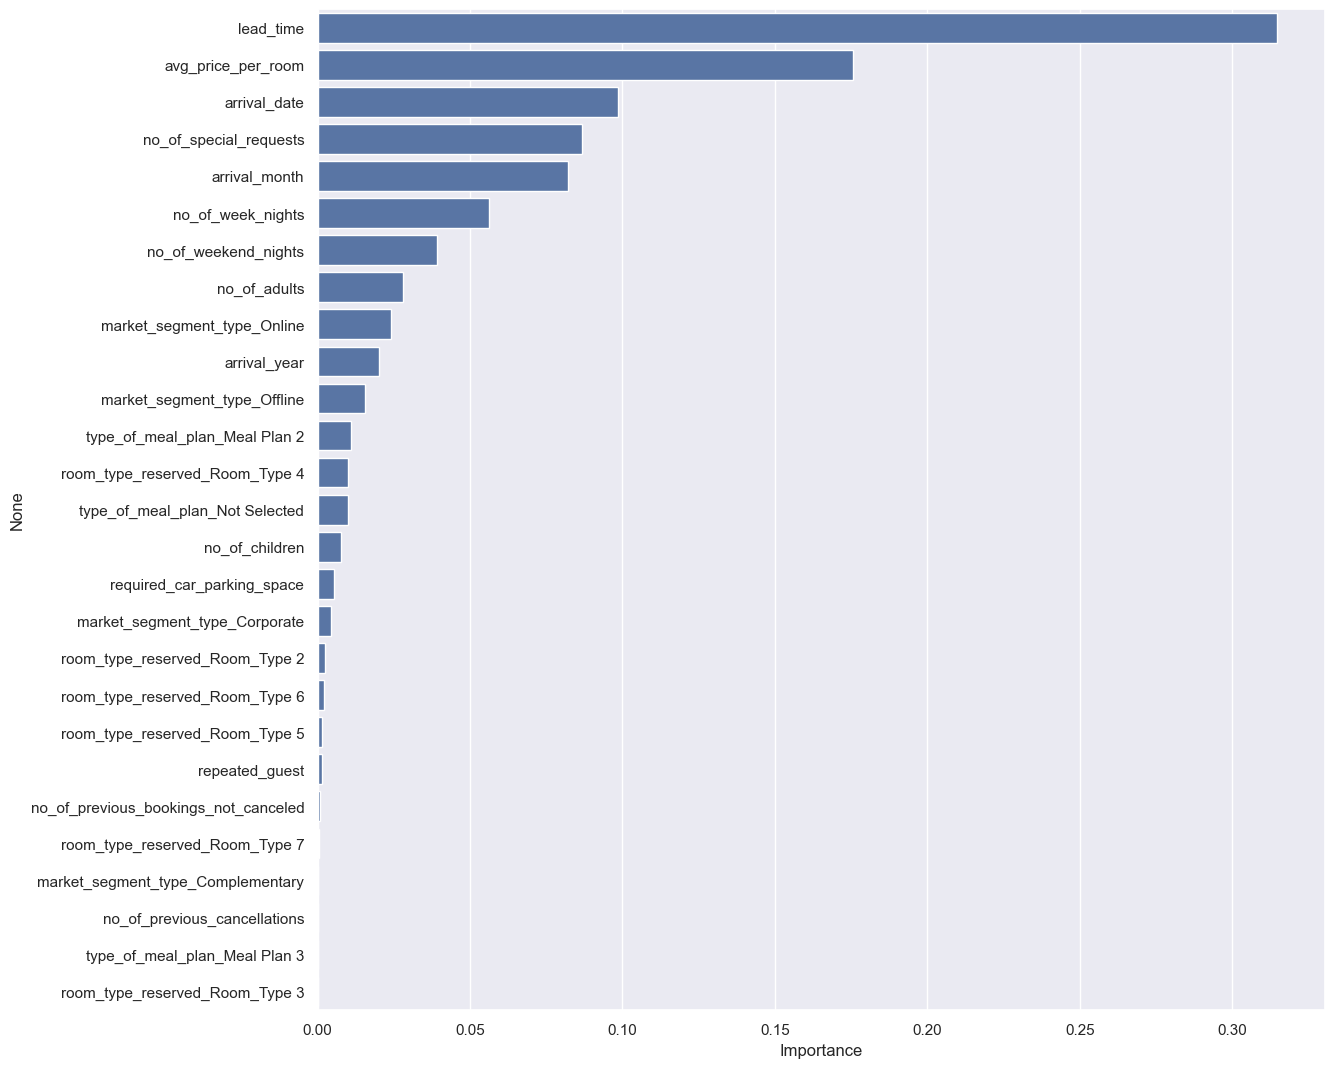

In [95]:
importances = rf_estimator.feature_importances_

columns = X.columns

importance_df = pd.DataFrame (importances , index = columns , columns = ['Importance'] ) .sort_values ( by = 'Importance', ascending = False )

plt.figure(figsize = (13, 13))

sns.barplot(x=importance_df.Importance, y=importance_df.index)

the random forest model demonstrates the importance of lead_time, similarly to the decision tree model, followed by avg_price_per_room, arrival_date, no_of_special_req, though the list of important factors is different than the decision tree model conclusion, the random forest model seems to be the best fit for the test data, with a highest overall accuracy.

## Key takeaways
1) Both false positives and false negatives misclassifications can potentially harm the business of the hotel, therefore any future changes should express intent to balance the overall precision and recall of identifying potential classifications ('cancelled' and 'not cancelled')

2) the overall average accuracy for the random forest model was consistently the most effective way to predict 'cancelled' classifications

3) Lead Time seems to be the most important feature when classifying the data.

4) it seems to be important to get first time guest to come back as it drastically reduces the chances of them cancelling their reservation.
